# C-MAPSS Modeling — `modeling_v1` · LSTM baseline on FD001

**Course project:** 24-788 Introduction to Deep Learning (Spring 2026), 2-person team
**This notebook:** the **baseline** — an LSTM trained on FD001 to predict Remaining Useful Life (RUL).
**Hardware target:** Apple Silicon (MPS), with CUDA / CPU fallback.
**Time budget:** ~10–12 minutes on an M4 MacBook Pro.

The modeling decisions in §15 of `eda_v1.ipynb` are baked in here:

- Drop near-constant sensors (`s_1, s_5, s_10, s_16, s_18, s_19`)
- Z-score the remaining sensors using **train-only** mean/std (FD001 is single-regime — no per-condition normalization needed)
- Sliding window length **W = 30**, stride 1
- RUL labels clipped at **125** during training, un-clipped at evaluation
- Evaluation: RMSE + the PHM asymmetric score (penalizes late predictions more than early ones)

Live training visuals follow the `GAN_Tracker` pattern from HW10 — `clear_output(wait=True)` + `display(fig)` to update plots in place every N iterations, alongside a `tqdm` progress bar with ETA.

The two model variants (Transformer + DANN) live in separate notebooks and reuse the data pipeline and Tracker class developed here.


## 1 · Setup

**Dependencies.** If running locally for the first time, install these in your environment:

```bash
pip install torch numpy pandas matplotlib seaborn tqdm jupyter ipykernel
```

`torch` on Apple Silicon ships with MPS support out of the box (no special wheel needed). All other libs are stock scientific Python.

Place the unzipped `CMAPSSData/` folder next to this notebook before running.


In [1]:
import os, time, random, math
from pathlib import Path
from typing import Sequence, Union, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display, clear_output

# Reproducibility — set every seed we can
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device pattern from HW10
if torch.cuda.is_available():
    Device = "cuda"
elif torch.backends.mps.is_available():
    Device = "mps"
else:
    Device = "cpu"
print(f"Device: {Device}")
print(f"PyTorch: {torch.__version__}")

sns.set_theme(style="whitegrid", context="notebook")

# Working dirs
DATA_DIR  = Path("CMAPSSData")
CKPT_DIR  = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR   = Path("figures");     FIG_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), f"Place CMAPSSData/ next to this notebook (or edit DATA_DIR)."


Device: mps
PyTorch: 2.11.0


## 2 · Data loading and preprocessing

We load FD001 train + test, build the RUL labels for the train trajectories, drop the flat sensors identified in EDA, then z-score the remaining sensors using statistics computed **on the training set only**. The test set uses the same statistics (no peeking).


In [2]:
COLS = (["unit", "cycle", "setting_1", "setting_2", "setting_3"]
        + [f"s_{i}" for i in range(1, 22)])
SENSORS_ALL = [c for c in COLS if c.startswith("s_")]

# From eda_v1 §5: these have ~zero within-engine std on FD001 → no degradation signal.
FLAT_SENSORS = ["s_1", "s_5", "s_10", "s_16", "s_18", "s_19"]
# We also drop s_6 — it varies discretely between two values across the population
# but has very weak correlation with RUL (see eda_v1 §11). Standard 14-sensor set.
DROP_SENSORS = FLAT_SENSORS + ["s_6"]
USE_SENSORS  = [s for s in SENSORS_ALL if s not in DROP_SENSORS]
print(f"Using {len(USE_SENSORS)} sensors: {USE_SENSORS}")

# Hyperparameters that come straight from EDA
W           = 30      # sliding window length
RUL_CLIP    = 125     # piecewise-linear RUL clipping for training labels
SUBSET      = "FD001" # this notebook is FD001-only

def load_subset(subset: str):
    train = pd.read_csv(DATA_DIR / f"train_{subset}.txt", sep=r"\s+",
                        header=None, names=COLS, engine="python")
    test  = pd.read_csv(DATA_DIR / f"test_{subset}.txt",  sep=r"\s+",
                        header=None, names=COLS, engine="python")
    rul   = pd.read_csv(DATA_DIR / f"RUL_{subset}.txt",   sep=r"\s+",
                        header=None, names=["RUL"],    engine="python")["RUL"].values
    return train, test, rul

train_df, test_df, true_rul = load_subset(SUBSET)
print(f"{SUBSET}: train rows={len(train_df):,}, test rows={len(test_df):,}, "
      f"train engines={train_df['unit'].nunique()}, test engines={test_df['unit'].nunique()}")


Using 14 sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
FD001: train rows=20,631, test rows=13,096, train engines=100, test engines=100


In [3]:
# Add the true RUL column to the training dataframe.
def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    return df

train_df = add_rul(train_df)

# Train-only normalization stats (we'll apply to both train and test)
train_means = train_df[USE_SENSORS].mean()
train_stds  = train_df[USE_SENSORS].std().replace(0, 1.0)

def normalize(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[USE_SENSORS] = (df[USE_SENSORS] - train_means) / train_stds
    return df

train_df = normalize(train_df)
test_df  = normalize(test_df)

print("Train RUL stats (un-clipped):",
      f"mean={train_df['RUL'].mean():.1f}, max={train_df['RUL'].max()}")
print("After clipping at", RUL_CLIP, "→",
      f"mean={train_df['RUL'].clip(upper=RUL_CLIP).mean():.1f}")
print("Sensor stats after normalization (should be ~0 mean, ~1 std):")
print(train_df[USE_SENSORS].describe().loc[["mean","std"]].T.round(3).head(8))


Train RUL stats (un-clipped): mean=107.8, max=361
After clipping at 125 → mean=86.8
Sensor stats after normalization (should be ~0 mean, ~1 std):
      mean  std
s_2    0.0  1.0
s_3   -0.0  1.0
s_4    0.0  1.0
s_7   -0.0  1.0
s_8    0.0  1.0
s_9   -0.0  1.0
s_11  -0.0  1.0
s_12  -0.0  1.0


## 3 · Sliding-window `Dataset`

For each training engine with trajectory length L ≥ W, we generate (L − W + 1) windows of shape (W, n_features), each labeled with the RUL **at the last cycle of the window**. Engines shorter than W are dropped (none on FD001 train).

For the test set, each engine contributes **one** window — the final W cycles of its truncated trajectory — and the label is the corresponding entry from `RUL_FD001.txt` (the true RUL at the last observed cycle). Engines with fewer than W observed cycles are front-padded by repeating the earliest cycle (this is the standard way the literature handles the small fraction of short test trajectories — see EDA §14).


In [4]:
class CMAPSSWindowDataset(Dataset):
    # Sliding-window dataset for training.
    # One sample per valid (engine, last_cycle_index) pair.
    def __init__(self, df: pd.DataFrame, sensors, window: int, rul_clip: int):
        self.window  = window
        self.sensors = sensors
        self.X = []
        self.y = []
        for _, eng in df.groupby("unit"):
            # Each engine's data sorted by cycle (which it already is).
            sensor_array = eng[sensors].values.astype(np.float32)   # (L, F)
            rul_array    = eng["RUL"].values.astype(np.float32)
            rul_array    = np.minimum(rul_array, rul_clip)
            L = len(eng)
            if L < window:
                continue
            for end in range(window, L + 1):  # end is exclusive index in slicing
                self.X.append(sensor_array[end - window : end])
                self.y.append(rul_array[end - 1])
        self.X = np.stack(self.X)             # (N, W, F)
        self.y = np.array(self.y, dtype=np.float32)

    def __len__(self):  return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i])


def build_test_windows(df: pd.DataFrame, sensors, window: int):
    # One window per test engine: the last `window` cycles, with front-padding
    # by repeating the first available cycle if the engine has < W cycles of history.
    Xs = []
    for unit, eng in df.groupby("unit"):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
        else:
            pad = np.tile(arr[0:1], (window - len(arr), 1))
            Xs.append(np.concatenate([pad, arr], axis=0))
    return np.stack(Xs)   # (n_test_engines, W, F)


# Build train / val split: hold out 20% of engines as validation
rng = np.random.default_rng(SEED)
all_units = train_df["unit"].unique()
val_units = rng.choice(all_units, size=int(0.2 * len(all_units)), replace=False)
val_mask  = train_df["unit"].isin(val_units)

train_set = CMAPSSWindowDataset(train_df[~val_mask], USE_SENSORS, W, RUL_CLIP)
val_set   = CMAPSSWindowDataset(train_df[ val_mask], USE_SENSORS, W, RUL_CLIP)

X_test = build_test_windows(test_df, USE_SENSORS, W)
y_test = true_rul.astype(np.float32)

print(f"Train windows: {len(train_set):,}  (from {len(all_units) - len(val_units)} engines)")
print(f"Val   windows: {len(val_set):,}  (from {len(val_units)} engines)")
print(f"Test  windows: {X_test.shape[0]:,}  (one per test engine)")
print(f"Window shape : (W={W}, F={len(USE_SENSORS)})")


Train windows: 14,070  (from 80 engines)
Val   windows: 3,661  (from 20 engines)
Test  windows: 100  (one per test engine)
Window shape : (W=30, F=14)


## 4 · LSTM model

Deliberately small and standard:

- 2-layer LSTM, hidden size 64
- Dropout 0.3 between layers (LSTM-internal) + 0.3 before the head
- Take the **last** hidden state, project through one FC layer (64 → 32 → 1)
- ~30k parameters total — fast to train, plenty of capacity for FD001

The output is a scalar predicted RUL. We train with MSE on clipped targets.


In [5]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features: int, hidden: int = 64, num_layers: int = 2,
                 dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):                  # x: (B, W, F)
        out, _ = self.lstm(x)              # (B, W, H)
        last   = out[:, -1, :]             # (B, H) — last timestep
        return self.head(last).squeeze(-1) # (B,)

# Sanity-check the forward pass shapes
_n_feat = len(USE_SENSORS)
_model = LSTMRegressor(_n_feat).to(Device)
_x = torch.randn(8, W, _n_feat, device=Device)
_y = _model(_x)
print(f"Model output shape: {tuple(_y.shape)}  (expected (8,))")
print(f"Total params      : {sum(p.numel() for p in _model.parameters()):,}")
del _model, _x, _y


Model output shape: (8,)  (expected (8,))
Total params      : 55,873


## 5 · Live training tracker

The same idea as `GAN_Tracker` in HW10: hold matplotlib axes, append to internal lists every step, and re-draw periodically by clearing the cell output and re-displaying the figure. Two subplots: loss curves (train + val) and RMSE curves (train + val) over epochs.

The `tqdm` bar inside the training loop shows the ETA.


In [6]:
class TrainTracker:
    # Live-updating per-epoch loss + RMSE plot.
    # update_epoch() is called once per epoch with the four scalars to log.

    def __init__(self, n_epochs: int, plot_freq: int = 1):
        self.n_epochs   = n_epochs
        self.plot_freq  = plot_freq
        self.epoch      = 0
        self.train_loss = []
        self.val_loss   = []
        self.train_rmse = []
        self.val_rmse   = []
        self.t0         = time.time()
        self._init_fig()

    def _init_fig(self):
        # Use ioff so the initial figure isn't auto-displayed before training starts;
        # we'll explicitly display it on the first update_epoch call.
        plt.ioff()
        self.fig, (self.ax_loss, self.ax_rmse) = plt.subplots(1, 2, figsize=(13, 4))

        # Loss subplot
        self.tl_curve, = self.ax_loss.plot([], [], label="train", color="steelblue")
        self.vl_curve, = self.ax_loss.plot([], [], label="val",   color="darkorange")
        self.ax_loss.set_xlim(0, self.n_epochs + 1)
        self.ax_loss.set_xlabel("Epoch")
        self.ax_loss.set_ylabel("MSE loss (clipped RUL)")
        self.ax_loss.set_title("Training loss")
        self.ax_loss.legend(); self.ax_loss.grid(linestyle="--", alpha=0.6)

        # RMSE subplot
        self.tr_curve, = self.ax_rmse.plot([], [], label="train", color="steelblue")
        self.vr_curve, = self.ax_rmse.plot([], [], label="val",   color="darkorange")
        self.ax_rmse.set_xlim(0, self.n_epochs + 1)
        self.ax_rmse.set_xlabel("Epoch")
        self.ax_rmse.set_ylabel("RMSE (cycles, clipped RUL)")
        self.ax_rmse.set_title("RMSE")
        self.ax_rmse.legend(); self.ax_rmse.grid(linestyle="--", alpha=0.6)

        plt.tight_layout()

    def update_epoch(self, train_loss: float, val_loss: float,
                     train_rmse: float, val_rmse: float):
        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)
        self.train_rmse.append(train_rmse)
        self.val_rmse.append(val_rmse)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()

    def _redraw(self):
        xs = list(range(1, self.epoch + 1))
        self.tl_curve.set_data(xs, self.train_loss)
        self.vl_curve.set_data(xs, self.val_loss)
        self.tr_curve.set_data(xs, self.train_rmse)
        self.vr_curve.set_data(xs, self.val_rmse)
        self.ax_loss.relim(); self.ax_loss.autoscale_view()
        self.ax_rmse.relim(); self.ax_rmse.autoscale_view()

        elapsed = time.time() - self.t0
        per_ep  = elapsed / self.epoch
        eta     = per_ep * (self.n_epochs - self.epoch)
        title = (f"Epoch {self.epoch}/{self.n_epochs}  ·  "
                 f"train RMSE={self.train_rmse[-1]:.2f}  ·  "
                 f"val RMSE={self.val_rmse[-1]:.2f}  ·  "
                 f"elapsed {elapsed:5.1f}s  ·  "
                 f"ETA {eta:5.1f}s")
        self.fig.suptitle(title, fontsize=11)

        clear_output(wait=True)
        display(self.fig)

    def close(self):
        # Call once after training to leave the final figure visible
        # without the live re-display flicker.
        plt.close(self.fig)


## 6 · Training loop

Standard PyTorch training: Adam optimizer, MSE loss on clipped RUL labels, gradient clipping at 1.0 (LSTMs sometimes spike), a cosine LR schedule for clean late-epoch convergence. We track the best val RMSE checkpoint and restore it at the end.

The progress bar shows per-batch ETA inside an epoch; the live plot updates per epoch.


In [7]:
def evaluate(model, loader, device):
    # Returns (mean MSE loss, RMSE in cycles) over the loader.
    model.eval()
    losses, sq_err, n = [], 0.0, 0
    crit = nn.MSELoss(reduction="sum")
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = crit(pred, yb)
            sq_err += loss.item()
            n += len(yb)
    rmse = math.sqrt(sq_err / n)
    return sq_err / n, rmse


def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    n_epochs: int = 60,
    lr: float = 1e-3,
    weight_decay: float = 1e-5,
    grad_clip: float = 1.0,
    device: str = Device,
    plot_freq: int = 1,
    ckpt_path: Optional[Path] = None,
):
    model = model.to(device)
    optim_ = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched  = optim.lr_scheduler.CosineAnnealingLR(optim_, T_max=n_epochs)
    crit   = nn.MSELoss()

    tracker = TrainTracker(n_epochs=n_epochs, plot_freq=plot_freq)
    history = []
    best_val = float("inf")
    best_epoch = 0

    epoch_pbar = tqdm(range(1, n_epochs + 1), desc="Training", unit="epoch")
    for epoch in epoch_pbar:
        # ── train ──────────────────────────────────────────────
        model.train()
        ep_loss, ep_sq, ep_n = 0.0, 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = crit(pred, yb)

            optim_.zero_grad()
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optim_.step()

            ep_loss += loss.item() * len(yb)
            ep_sq   += ((pred - yb) ** 2).sum().item()
            ep_n    += len(yb)
        sched.step()

        train_loss = ep_loss / ep_n
        train_rmse = math.sqrt(ep_sq / ep_n)

        # ── validate ──────────────────────────────────────────
        val_loss, val_rmse = evaluate(model, val_loader, device)

        history.append(dict(
            epoch=epoch, train_loss=train_loss, val_loss=val_loss,
            train_rmse=train_rmse, val_rmse=val_rmse,
            lr=sched.get_last_lr()[0],
        ))
        tracker.update_epoch(train_loss, val_loss, train_rmse, val_rmse)
        epoch_pbar.set_postfix({"train_RMSE": f"{train_rmse:.2f}",
                                "val_RMSE":   f"{val_rmse:.2f}"})

        # ── checkpoint ───────────────────────────────────────
        if val_rmse < best_val:
            best_val   = val_rmse
            best_epoch = epoch
            if ckpt_path is not None:
                torch.save(
                    {"model": model.state_dict(),
                     "epoch": epoch, "val_rmse": val_rmse,
                     "train_means": train_means, "train_stds": train_stds},
                    ckpt_path,
                )

    tracker.close()
    print(f"\nBest val RMSE = {best_val:.3f} at epoch {best_epoch}")

    # Reload best checkpoint
    if ckpt_path is not None and ckpt_path.exists():
        sd = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(sd["model"])
        print(f"Loaded best checkpoint from epoch {sd['epoch']}.")

    return model, pd.DataFrame(history)


## 7 · Train the baseline

Hyperparameters are chosen for ~10 minutes on M4 + MPS with reasonable convergence on FD001:

- Batch size: 512 (large batch is fine on FD001 — only ~17k training windows)
- Epochs: 60 (cosine LR; converges around epoch 40–50)
- LR: 1e-3, weight decay 1e-5
- Grad clip: 1.0


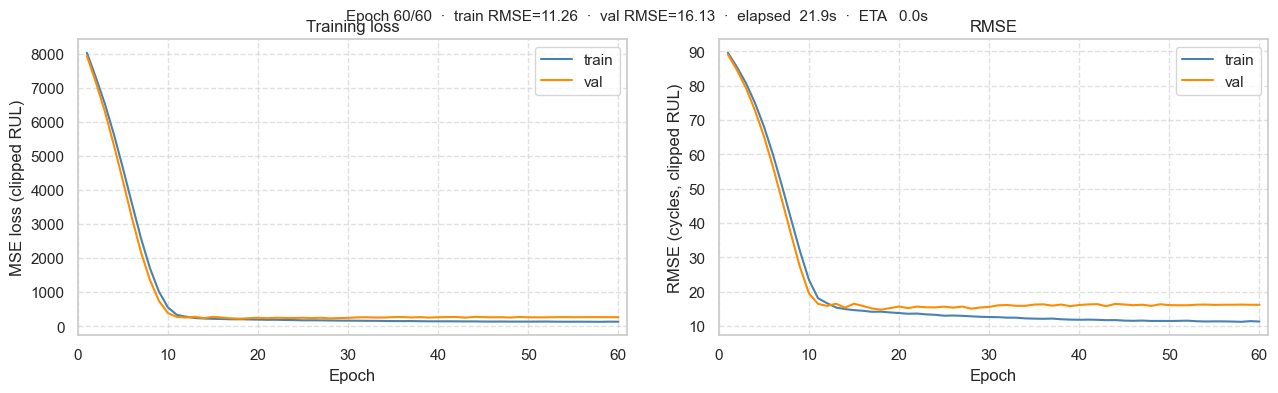


Best val RMSE = 14.706 at epoch 18
Loaded best checkpoint from epoch 18.


In [8]:
BATCH_SIZE = 512
N_EPOCHS   = 60
LR         = 1e-3

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=False, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          drop_last=False, num_workers=0)

model = LSTMRegressor(n_features=len(USE_SENSORS), hidden=64,
                      num_layers=2, dropout=0.3)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

ckpt_path = CKPT_DIR / f"lstm_{SUBSET}_best.pt"
model, history = train(
    model, train_loader, val_loader,
    n_epochs=N_EPOCHS, lr=LR,
    device=Device, plot_freq=1, ckpt_path=ckpt_path,
)


## 8 · Final training curves

The live tracker shows the latest figure but it's worth saving a clean static version for the report.


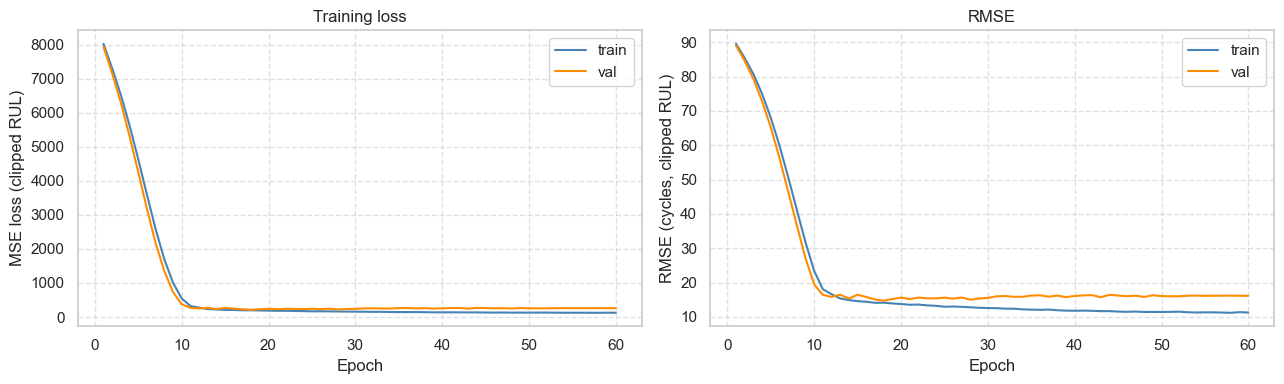

Saved → figures/lstm_FD001_curves.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history["epoch"], history["train_loss"], label="train", color="steelblue")
ax1.plot(history["epoch"], history["val_loss"],   label="val",   color="darkorange")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE loss (clipped RUL)")
ax1.set_title("Training loss"); ax1.legend(); ax1.grid(linestyle="--", alpha=0.6)

ax2.plot(history["epoch"], history["train_rmse"], label="train", color="steelblue")
ax2.plot(history["epoch"], history["val_rmse"],   label="val",   color="darkorange")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("RMSE (cycles, clipped RUL)")
ax2.set_title("RMSE"); ax2.legend(); ax2.grid(linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / f"lstm_{SUBSET}_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / f'lstm_{SUBSET}_curves.png'}")


## 9 · Test-set evaluation

Two metrics that the PHM community standardizes on:

1. **RMSE** in cycles (lower is better). For reference, Zheng et al. 2017 report ≈ 16.1 on FD001 with their Deep LSTM; current state of the art is around 11–12.
2. **Asymmetric score** — penalizes late predictions (predicting failure after it actually occurs) more heavily than early ones, which matches the maintenance-cost reality. The exact formula is in the project description (eqs. 6 & 7).

We evaluate on the test set with **un-clipped** true labels (per the project rubric — clipping is a training-time trick to focus loss, but evaluation should reflect reality).


In [10]:
def asymmetric_score(y_true, y_pred):
    # Standard PHM 2008 score: e^(-d/13)-1 for early, e^(d/10)-1 for late.
    d = y_pred - y_true
    score = np.where(d < 0,
                     np.exp(-d / 13.0) - 1,
                     np.exp( d / 10.0) - 1)
    return score.sum()

@torch.no_grad()
def predict_test(model, X_test, device, batch_size=256):
    model.eval()
    preds = []
    for i in range(0, len(X_test), batch_size):
        xb = torch.from_numpy(X_test[i:i+batch_size]).to(device)
        preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)

# Predictions and metrics
y_pred_raw = predict_test(model, X_test, Device)
# At inference time, predictions can saturate above the clip — clamp non-negatively
y_pred = np.clip(y_pred_raw, 0, None)

rmse_test = math.sqrt(np.mean((y_pred - y_test) ** 2))
score_test = asymmetric_score(y_test, y_pred)

print(f"Test RMSE          : {rmse_test:.3f} cycles")
print(f"Test asym. score   : {score_test:.1f}")
print(f"Mean abs error     : {np.mean(np.abs(y_pred - y_test)):.3f} cycles")
print(f"Reference (Zheng17): RMSE ~16, Score ~339 on FD001")


Test RMSE          : 21.045 cycles
Test asym. score   : 644.0
Mean abs error     : 16.031 cycles
Reference (Zheng17): RMSE ~16, Score ~339 on FD001


## 10 · Predicted vs true RUL scatter

Each point is one test engine. The diagonal is perfect prediction; points above the diagonal are **late** predictions (model said the engine has more life than it does — bad), points below are **early** (model said failure is closer than it is — safer in a maintenance sense, but pessimistic).


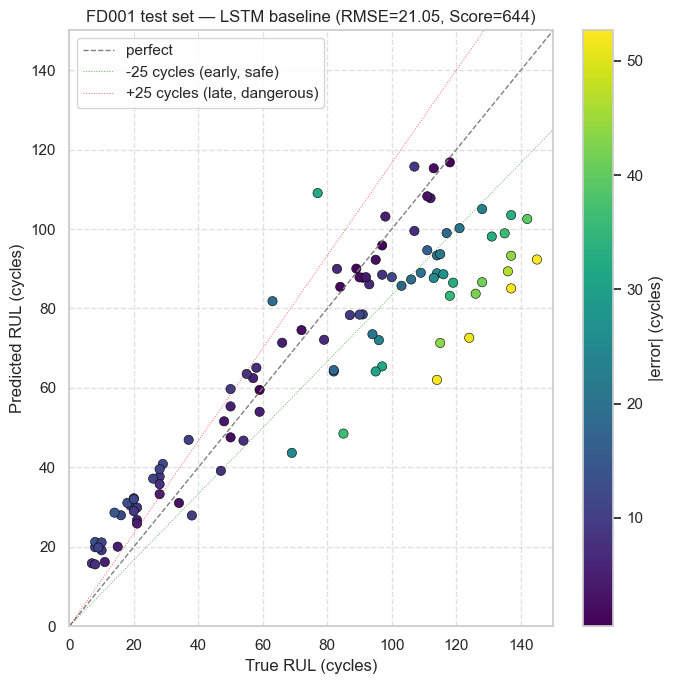

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

# Diagonal lines for reference
lim = max(y_test.max(), y_pred.max()) + 5
ax.plot([0, lim], [0, lim], "--", color="gray", lw=1, label="perfect")
ax.plot([0, lim], [0, lim - 25], ":", color="green", lw=0.7, alpha=0.6,
        label="-25 cycles (early, safe)")
ax.plot([0, lim], [0, lim + 25], ":", color="red", lw=0.7, alpha=0.6,
        label="+25 cycles (late, dangerous)")

# Color points by absolute error magnitude
errs = np.abs(y_pred - y_test)
sc = ax.scatter(y_test, y_pred, c=errs, cmap="viridis", s=45,
                edgecolor="black", linewidth=0.4)
plt.colorbar(sc, ax=ax, label="|error| (cycles)")

ax.set_xlabel("True RUL (cycles)")
ax.set_ylabel("Predicted RUL (cycles)")
ax.set_title(f"FD001 test set — LSTM baseline (RMSE={rmse_test:.2f}, Score={score_test:.0f})")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(loc="upper left")
ax.grid(linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / f"lstm_{SUBSET}_pred_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()


## 11 · Error distribution

A model-quality summary that complements the scatter: are errors symmetric around zero, or is the model systematically biased one way?


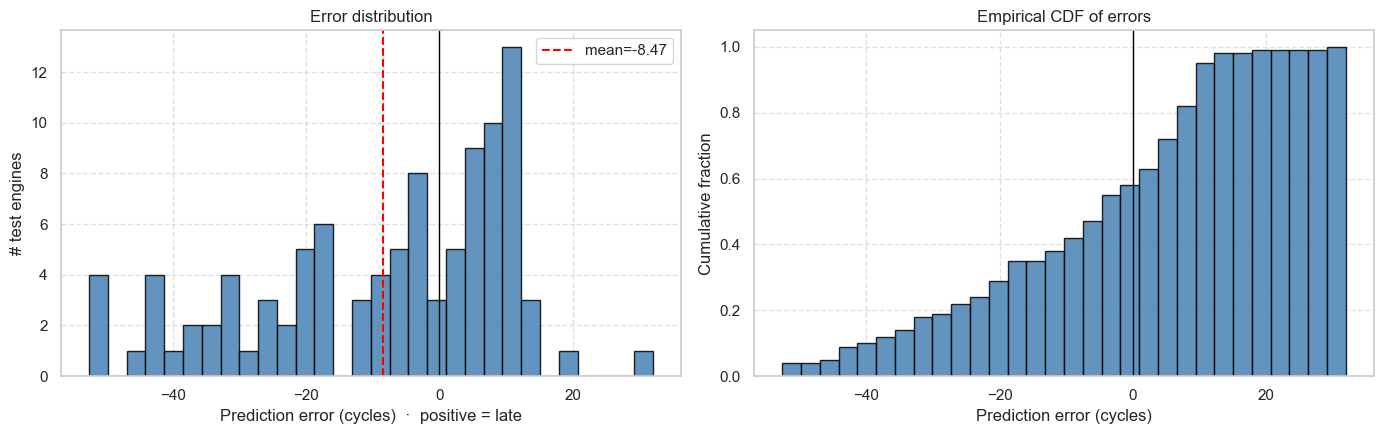

Bias (mean error)     : -8.47 cycles
Std of errors         : 19.27
Fraction of late preds: 43.0%
Fraction within +/-10 : 46.0%


In [12]:
errors = y_pred - y_test  # signed: positive = late, negative = early

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(errors, bins=30, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].axvline(0, color="black", lw=1)
axes[0].axvline(errors.mean(), color="red", linestyle="--",
                label=f"mean={errors.mean():+.2f}")
axes[0].set_xlabel("Prediction error (cycles)  ·  positive = late")
axes[0].set_ylabel("# test engines")
axes[0].set_title("Error distribution")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.6)

axes[1].hist(errors, bins=30, color="steelblue", edgecolor="black",
             cumulative=True, density=True, alpha=0.85)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("Prediction error (cycles)")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Empirical CDF of errors")
axes[1].grid(linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / f"lstm_{SUBSET}_error_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Bias (mean error)     : {errors.mean():+.2f} cycles")
print(f"Std of errors         : {errors.std():.2f}")
print(f"Fraction of late preds: {(errors > 0).mean():.1%}")
print(f"Fraction within +/-10 : {(np.abs(errors) <= 10).mean():.1%}")


## 12 · Per-engine RUL trajectories

For a few selected test engines, we run the model on **every** sliding window in the trajectory (not just the final one) to visualize how the prediction evolves as the engine accumulates more cycles. This is a useful qualitative check — a good model should track the true RUL line increasingly closely as failure approaches.


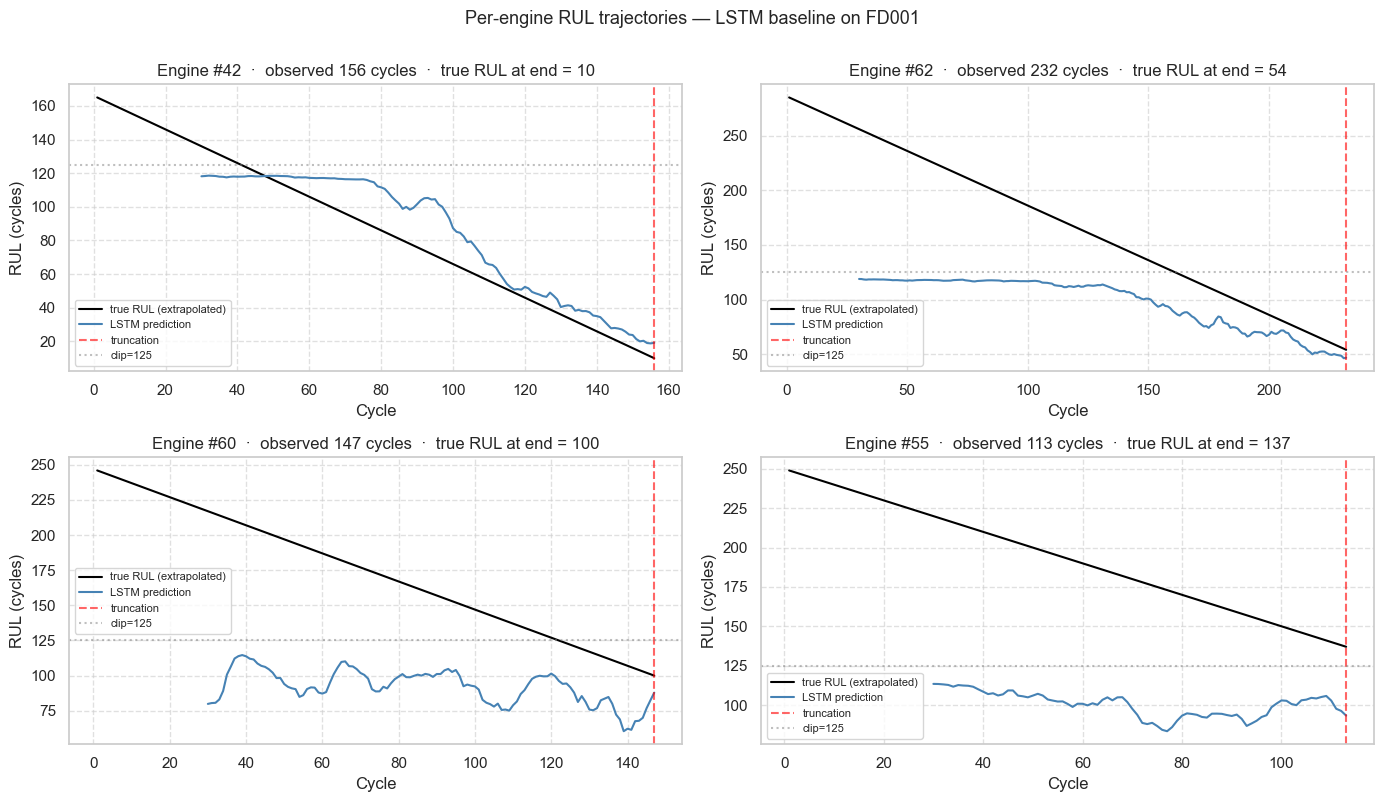

In [13]:
@torch.no_grad()
def predict_engine_trajectory(model, eng_df, sensors, window, device):
    # Run the model on every window of length `window` over a single engine.
    arr = eng_df[sensors].values.astype(np.float32)
    L = len(arr)
    if L < window:
        return None, None
    Xs = np.stack([arr[i:i+window] for i in range(L - window + 1)])
    xb = torch.from_numpy(Xs).to(device)
    preds = model(xb).cpu().numpy()
    cycles_at_pred = np.arange(window, L + 1)  # the "now" cycle for each prediction
    return cycles_at_pred, preds

# Pick 4 test engines spanning a range of true-RUL values
last_cycles = test_df.groupby("unit")["cycle"].max()
order = np.argsort(y_test)  # easiest to hardest (highest RUL = least info)
chosen = [order[5], order[len(order)//3], order[2*len(order)//3], order[-5]]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
model.eval()

for ax, idx in zip(axes, chosen):
    unit = idx + 1   # units are 1-indexed
    eng = test_df[test_df["unit"] == unit]
    cycles_pred, preds = predict_engine_trajectory(model, eng, USE_SENSORS, W, Device)
    if cycles_pred is None:
        continue

    L = len(eng)
    true_at_last = y_test[idx]
    # The true RUL at every cycle of the *test* trajectory: we don't have full
    # ground truth, but at the truncation point the true RUL is `true_at_last`,
    # and we can extrapolate backwards (linearly: each earlier cycle has +1 RUL).
    cycles = np.arange(1, L + 1)
    true_rul_extrapolated = true_at_last + (L - cycles)

    ax.plot(cycles, true_rul_extrapolated, color="black", lw=1.5,
            label="true RUL (extrapolated)")
    ax.plot(cycles_pred, np.clip(preds, 0, None), color="steelblue", lw=1.5,
            label="LSTM prediction")
    ax.axvline(L, color="red", linestyle="--", alpha=0.6, label="truncation")
    ax.axhline(RUL_CLIP, color="gray", linestyle=":", alpha=0.5, label=f"clip={RUL_CLIP}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("RUL (cycles)")
    ax.set_title(f"Engine #{unit}  ·  observed {L} cycles  ·  true RUL at end = {true_at_last:.0f}")
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.6)

plt.suptitle("Per-engine RUL trajectories — LSTM baseline on FD001", y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / f"lstm_{SUBSET}_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()


## 13 · Save results + summary

Persist the metrics and the training history so the report and the model-comparison notebook can read them without retraining.


In [14]:
# Save the per-epoch history and final metrics for downstream use
history.to_csv(CKPT_DIR / f"lstm_{SUBSET}_history.csv", index=False)

results = {
    "subset":        SUBSET,
    "model":         "LSTM-baseline",
    "n_params":      int(sum(p.numel() for p in model.parameters())),
    "best_val_rmse": float(history["val_rmse"].min()),
    "test_rmse":     float(rmse_test),
    "test_score":    float(score_test),
    "test_mae":      float(np.mean(np.abs(y_pred - y_test))),
    "n_epochs":      int(N_EPOCHS),
    "batch_size":    int(BATCH_SIZE),
    "window":        int(W),
    "n_features":    len(USE_SENSORS),
    "device":        Device,
}
import json
with open(CKPT_DIR / f"lstm_{SUBSET}_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved:")
print(f"  - checkpoint: {ckpt_path}")
print(f"  - history   : {CKPT_DIR / f'lstm_{SUBSET}_history.csv'}")
print(f"  - results   : {CKPT_DIR / f'lstm_{SUBSET}_results.json'}")
print(f"  - figures   : {FIG_DIR}/lstm_{SUBSET}_*.png")
print()
print("=" * 60)
print(f"FINAL — LSTM baseline on {SUBSET}")
print("=" * 60)
for k, v in results.items():
    if isinstance(v, float):
        print(f"  {k:<15}: {v:.3f}")
    else:
        print(f"  {k:<15}: {v}")


Saved:
  - checkpoint: checkpoints/lstm_FD001_best.pt
  - history   : checkpoints/lstm_FD001_history.csv
  - results   : checkpoints/lstm_FD001_results.json
  - figures   : figures/lstm_FD001_*.png

FINAL — LSTM baseline on FD001
  subset         : FD001
  model          : LSTM-baseline
  n_params       : 55873
  best_val_rmse  : 14.706
  test_rmse      : 21.045
  test_score     : 643.976
  test_mae       : 16.031
  n_epochs       : 60
  batch_size     : 512
  window         : 30
  n_features     : 14
  device         : mps


## Next steps

This baseline is the reference number every other model has to beat. Two contributions to layer on top, in separate notebooks:

1. **`modeling_v2_transformer.ipynb`** — same data pipeline, swap LSTM for a small encoder-only Transformer (2–4 layers, 4 heads, model dim 64). Train on FD001. Compare RMSE/score head-to-head.
2. **`modeling_v3_dann.ipynb`** — keep the LSTM encoder, add a domain classifier head through a Gradient Reversal Layer (Ganin et al. 2016). Train with labeled FD001 + unlabeled FD002. Evaluate on FD002 test set against:
   - **Lower bound:** this baseline LSTM (FD001-trained) evaluated naively on FD002
   - **Upper bound:** an LSTM trained directly on labeled FD002

The story for the report writes itself: how much of the FD001→FD002 generalization gap can DANN close using only unlabeled target data?
